In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Simulated GTSRB-style traffic sign data
CLASS_NAMES = [
    "Speed 30",
    "Speed 60",
    "Speed 90",
    "Stop",
    "No Entry",
    "Yield",
    "Pedestrian Crossing",
    "No Overtaking"
]

N_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 32
N_PER_CLASS = 250

def make_class_images(class_idx, n):
    imgs = np.zeros((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

    for i in range(n):
        img = np.random.rand(IMG_SIZE, IMG_SIZE, 3) * 0.15

        if class_idx == 0:
            img[:, :10, 0] += 0.8

        elif class_idx == 1:
            img[:, 11:21, 1] += 0.8

        elif class_idx == 2:
            img[:, 22:, 2] += 0.8

        elif class_idx == 3:
            img[8:24, 8:24, :] = [1, 0, 0]

        elif class_idx == 4:
            img[6:26, 6:26, :] = [1, 1, 1]
            img[10:22, 10:22, :] = [1, 0, 0]

        elif class_idx == 5:
            for r in range(IMG_SIZE):
                img[r, :r, :] += [1, 1, 0]

        elif class_idx == 6:
            img[12:20, :, :] = [1, 1, 1]

        elif class_idx == 7:
            img[:, :, :] += [0.3, 0.3, 0.3]
            img[:, 14:18, :] = [1, 1, 1]

        imgs[i] = np.clip(img, 0, 1)

    return imgs

In [ ]:
X_list = []
y_list = []

for c in range(N_CLASSES):
    imgs = make_class_images(c, N_PER_CLASS)
    X_list.append(imgs)
    y_list.append(np.full(N_PER_CLASS, c))

X = np.concatenate(X_list).astype("float32")
y = np.concatenate(y_list)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Number of Classes:", N_CLASSES)

Dataset Shape: (2000, 32, 32, 3)
Labels Shape: (2000,)
Number of Classes: 8


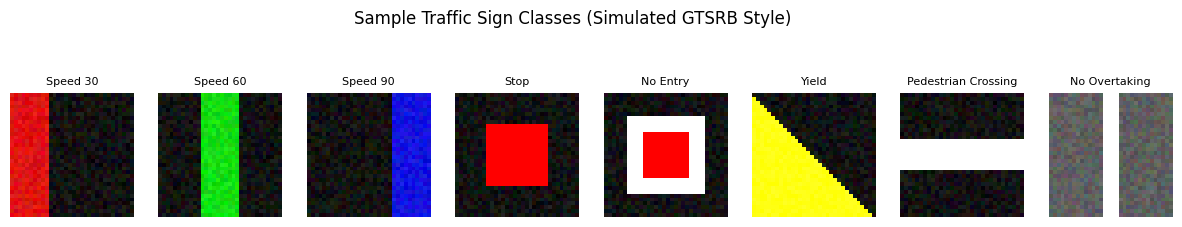

In [ ]:
fig, axes = plt.subplots(1, N_CLASSES, figsize=(15,3))

for c in range(N_CLASSES):
    axes[c].imshow(X[c * N_PER_CLASS])
    axes[c].set_title(CLASS_NAMES[c], fontsize=8)
    axes[c].axis("off")

plt.suptitle("Sample Traffic Sign Classes (Simulated GTSRB Style)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat = to_categorical(y_test, N_CLASSES)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1600, 32, 32, 3)
Testing Data: (400, 32, 32, 3)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(N_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,840 (2.08 MB)

 Trainable params: 544,840 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9426 - loss: 0.2268 - val_accuracy: 1.0000 - val_loss: 2.3146e-06
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 1.0000 - loss: 6.1045e-05 - val_accuracy: 1.0000 - val_loss: 1.1673e-06
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 1.0000 - loss: 4.9077e-05 - val_accuracy: 1.0000 - val_loss: 9.0251e-07
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 1.0000 - loss: 4.4756e-05 - val_accuracy: 1.0000 - val_loss: 6.9340e-07
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 1.0000 - loss: 4.8589e-04 - val_accuracy: 1.0000 - val_loss: 3.1319e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9993 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 2.2997e-07
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 1.0000 - loss: 9.6300e-06 - val_accuracy: 1.0000 - val_loss: 3.9240e-08
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 

Test Accuracy: 1.0
Test Loss: 0.0


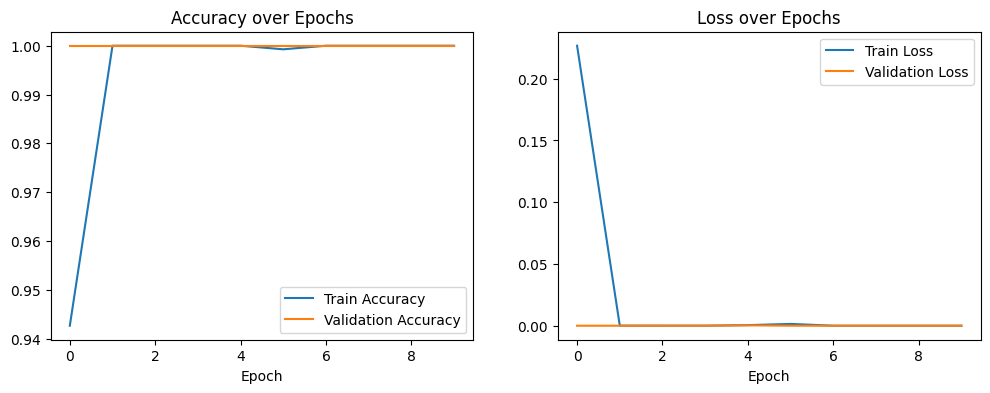

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Accuracy:", round(test_acc,3))
print("Test Loss:", round(test_loss,3))

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.show()

                     precision    recall  f1-score   support

           Speed 30       1.00      1.00      1.00        50
           Speed 60       1.00      1.00      1.00        50
           Speed 90       1.00      1.00      1.00        50
               Stop       1.00      1.00      1.00        50
           No Entry       1.00      1.00      1.00        50
              Yield       1.00      1.00      1.00        50
Pedestrian Crossing       1.00      1.00      1.00        50
      No Overtaking       1.00      1.00      1.00        50

           accuracy                           1.00       400
          macro avg       1.00      1.00      1.00       400
       weighted avg       1.00      1.00      1.00       400



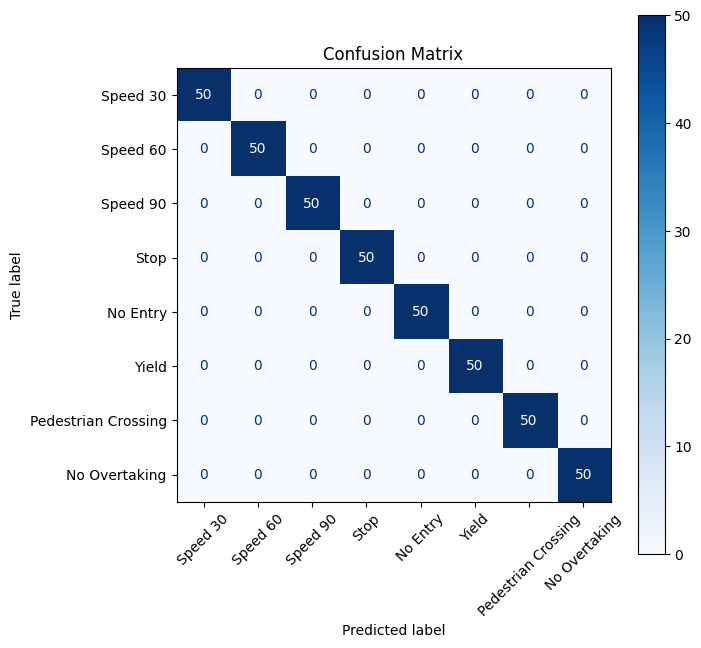

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES
))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7,7))

ConfusionMatrixDisplay(
    cm,
    display_labels=CLASS_NAMES
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

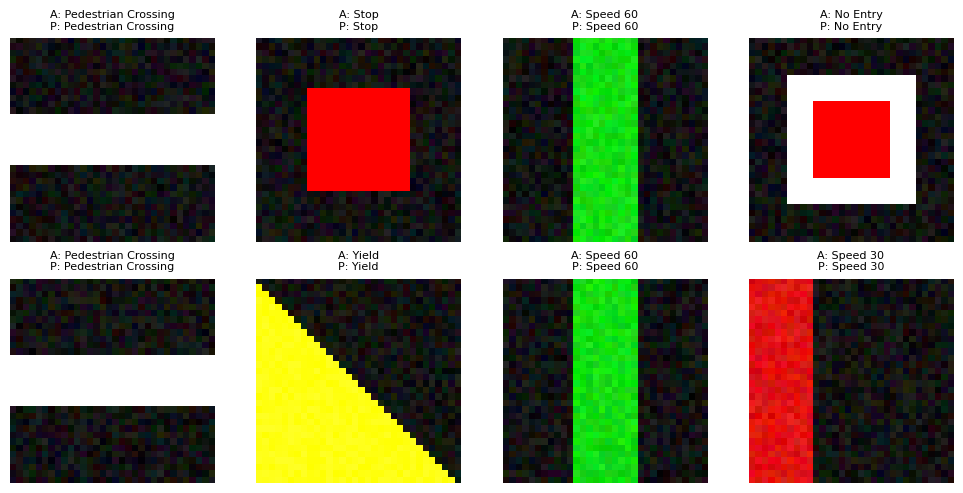

In [ ]:
pred = np.argmax(model.predict(X_test[:8], verbose=0), axis=1)

fig, axes = plt.subplots(2,4, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    ax.set_title(
        "A: {}\nP: {}".format(
            CLASS_NAMES[y_test[i]],
            CLASS_NAMES[pred[i]]
        ),
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()